In [27]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.interpolate import interp1d
import matplotlib.ticker as mticker




In [2]:
example_output = '../../../../data/bamfeatures/testoutput/hes_star2.annot'

In [3]:
# length_input = '../../../../data/gtf/Saccharomyces_cerevisiae.R64-1-1.75.lengths'

In [4]:
length_input = '../../../../data/gtf/Homo_sapiens.GRCh37.75.lengths'

In [5]:
df = pd.read_csv(length_input, sep='\t')
length_dict = df.set_index(df.columns[0]).T.to_dict()

In [6]:
def add_to_pcr_index(pcr_index_count, pcr_index):
    if pcr_index in pcr_index_count:
        pcr_index_count[pcr_index] += 1
    else:
        pcr_index_count[pcr_index] = 1

In [7]:
def add_to_gene_dict(gene_dict, gene_id, pcr_index):
    if gene_id in gene_dict:
        gene_dict[gene_id] = (gene_dict[gene_id][0] + 1, gene_dict[gene_id][1] + (1 if pcr_index == '0' else 0))
    else:
        gene_dict[gene_id] = (1, 1 if pcr_index == '0' else 0)

In [8]:
# Open example_output line by line
genic_count = 0
split_inconsistent_count = 0
gdist_count = 0
transcriptomic_count = 0
merged_transcriptomic_count = 0
intronic_count = 0
gene_dict = {}
pcr_index_count = {}
all_anotated = 0
gdists = []
genic_count_more_one_gene=0

# TODO Biotype count
with open(example_output, 'r') as file:
    for line in file:
        parts = line.strip().split("\t")
        if (parts[1][0] == 'm'):
            if parts[4][7] != '0':
                genic_count += 1
                # Now check whether it's transcriptomic, merged or intronic
                splitmatch = parts[5].split("|")
                if len(splitmatch) > 1:
                    genic_count_more_one_gene += 1
                for matching_gene in splitmatch:
                    matching_gene_parts = matching_gene.split(":")
                    gene_id = matching_gene_parts[0].split(",")[0]
                    pcr_index = parts[6].split(" ")[1]
                    add_to_pcr_index(pcr_index_count, pcr_index)
                    add_to_gene_dict(gene_dict, gene_id, pcr_index)
                    if matching_gene_parts[1].startswith("MERGED"):
                        merged_transcriptomic_count += 1
                    elif matching_gene_parts[1].startswith("INTRON"):
                        intronic_count += 1
                    else:
                        transcriptomic_count += 1

            else:
                gdist_count += 1
                gdists.append(parts[5].split(":")[1])
        else:
            split_inconsistent_count += 1
        all_anotated+=1


In [9]:
def calc_rpkm(num_reads, total_genes_matched, gene_length):
    return (num_reads * 1_000 * 1_000_000.0) / (total_genes_matched * gene_length)

In [10]:
rows = []

# Iterate through the gene_dict
for gene_id, vals in gene_dict.items():
    length = length_dict[gene_id]["length"]
    chr = length_dict[gene_id]["chromosome"]
    total_rpkm = calc_rpkm(vals[0], genic_count, length)
    unique_rpkm = calc_rpkm(vals[1], genic_count, length)

    # Append a dictionary to the list
    rows.append({
        'chromosome': chr,
        'gene_id': gene_id,
        'total_rpkm': total_rpkm,
        'unique_rpkm': unique_rpkm
    })

# Create the DataFrame from the list of rows
rpkm_df = pd.DataFrame(rows, columns=['chromosome', 'gene_id', 'total_rpkm', 'unique_rpkm'])

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


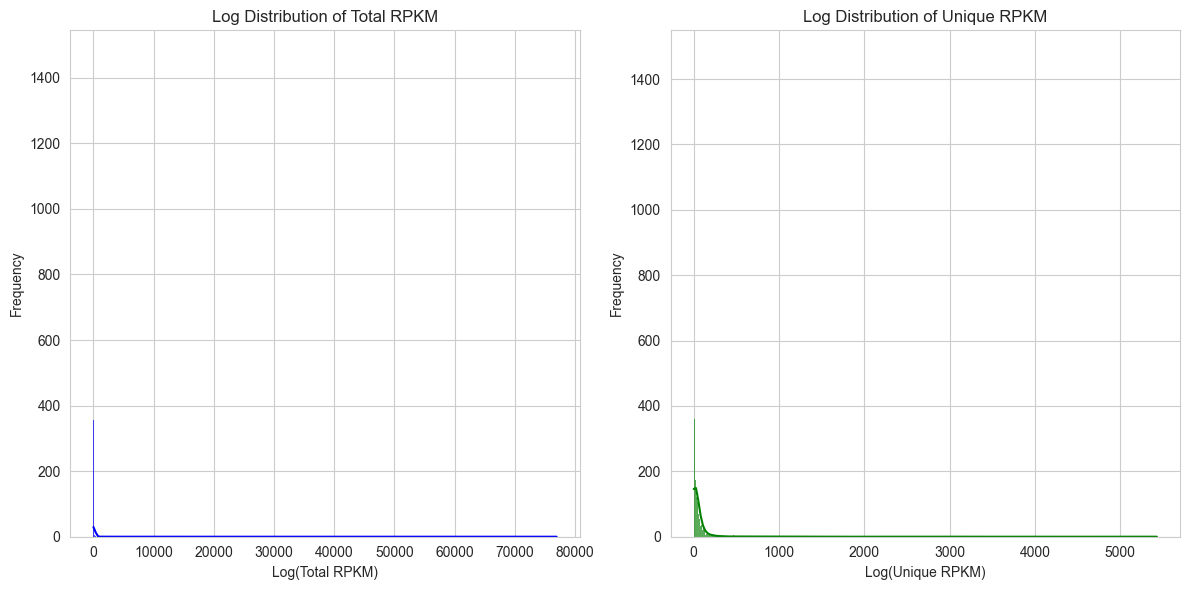

In [11]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Plot histogram and KDE for log(total_rpkm)
sns.histplot(rpkm_df['total_rpkm'], bins='auto', kde=True, ax=axes[0], color='blue', alpha=0.7)
axes[0].set_title('Log Distribution of Total RPKM')
axes[0].set_xlabel('Log(Total RPKM)')
axes[0].set_ylabel('Frequency')

# Plot histogram and KDE for log(unique_rpkm)
sns.histplot(rpkm_df['unique_rpkm'], bins='auto', kde=True, ax=axes[1], color='green', alpha=0.7)
axes[1].set_title('Log Distribution of Unique RPKM')
axes[1].set_xlabel('Log(Unique RPKM)')
axes[1].set_ylabel('Frequency')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


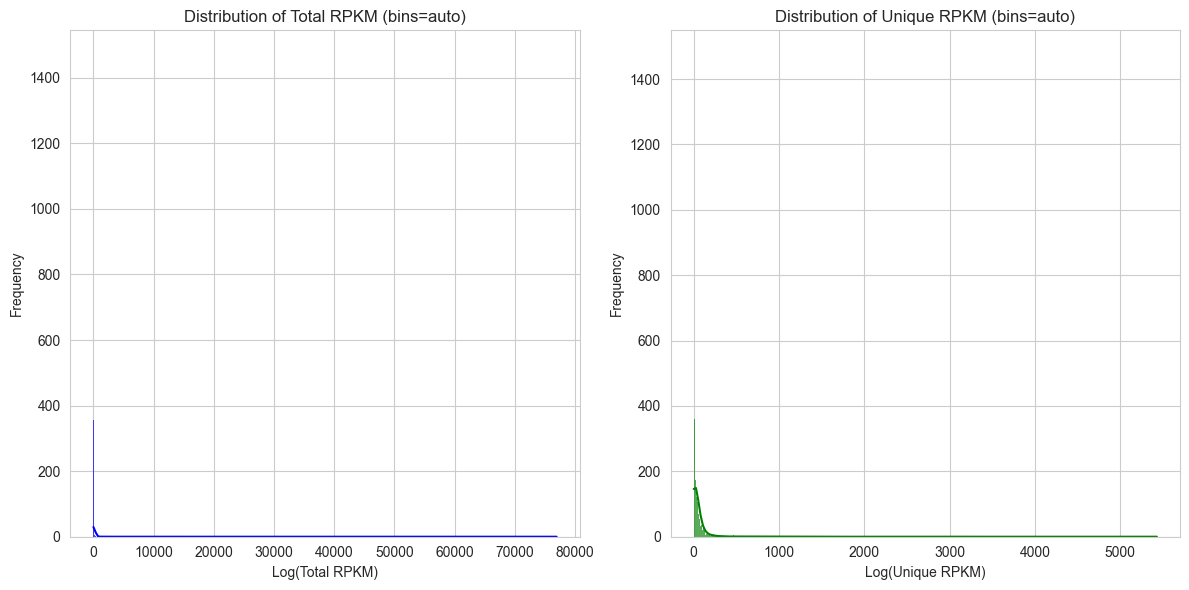

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


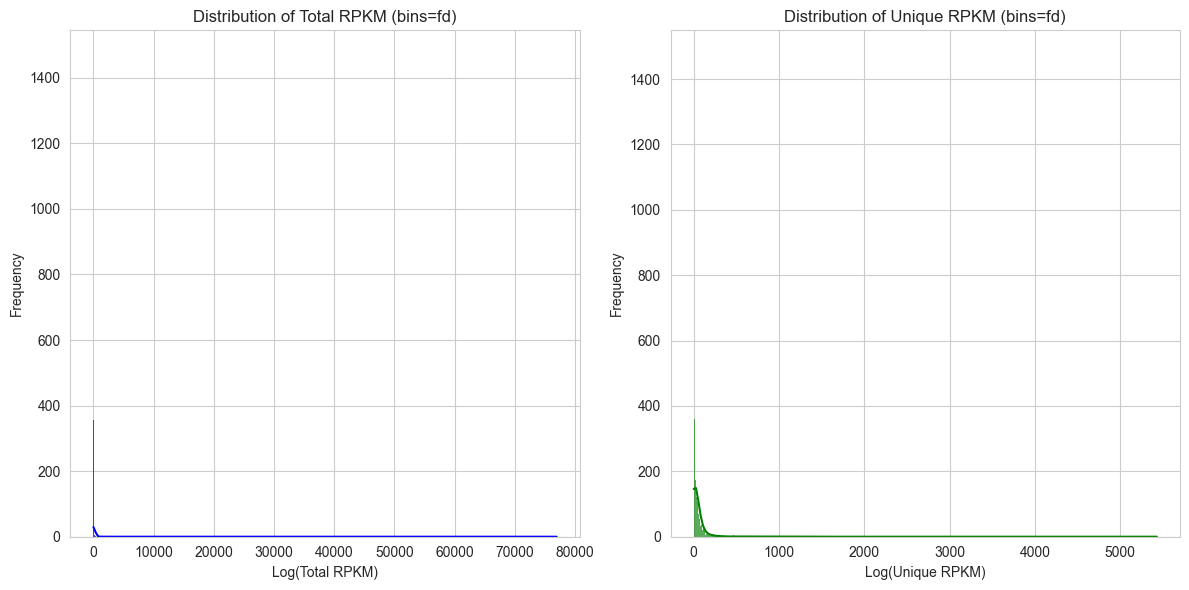

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


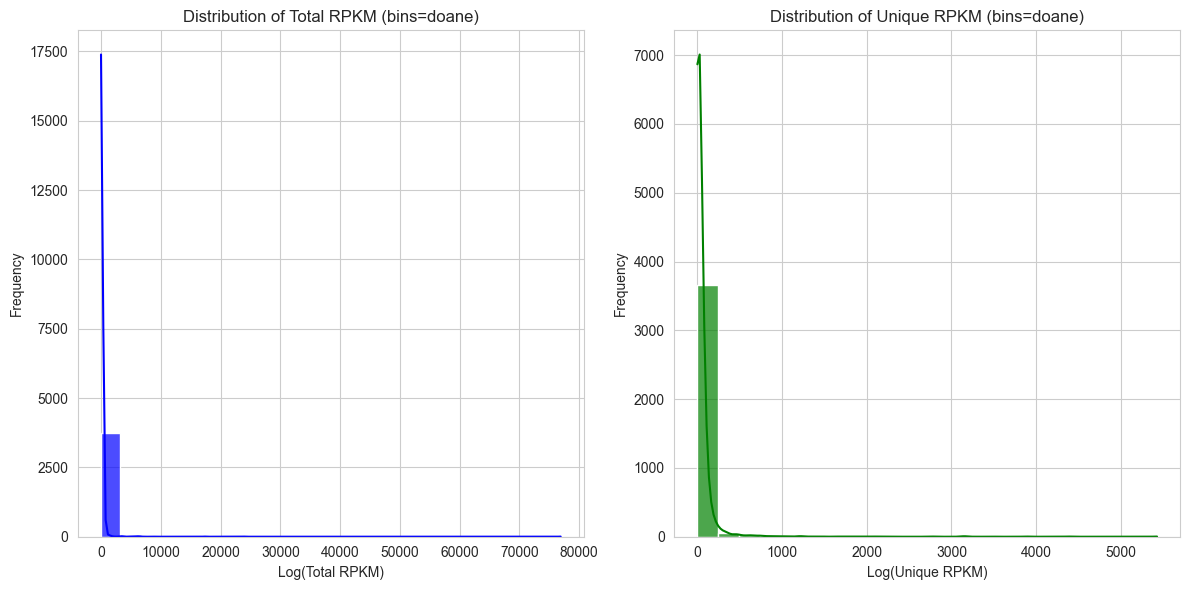

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


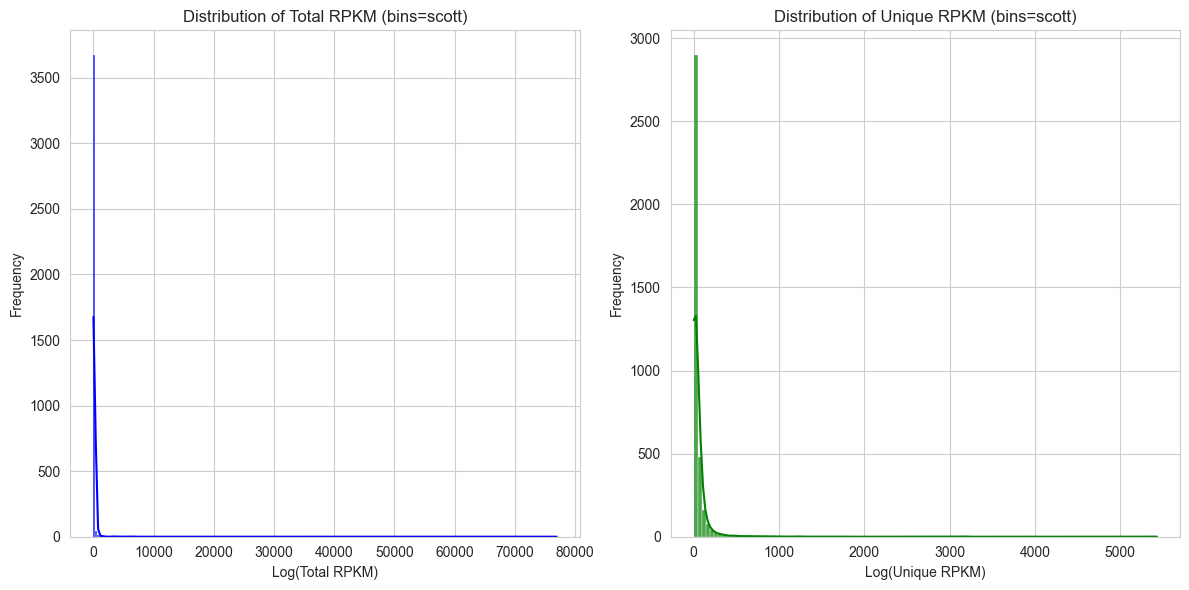

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/numpy/lib/histograms.py:669: RuntimeWarning: The number of bins estimated may be suboptimal.
  bin_edges, _ = _get_bin_edges(a, bins, range, weights)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/numpy/lib/histograms.py:669: RuntimeWarning: The number of bins estimated may be sub

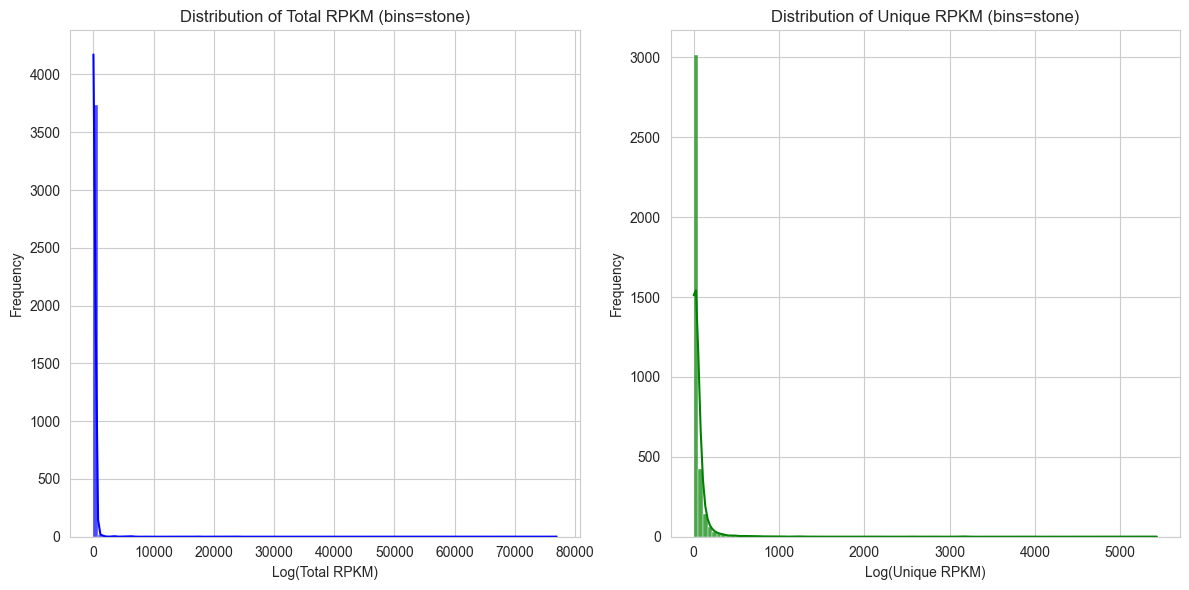

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


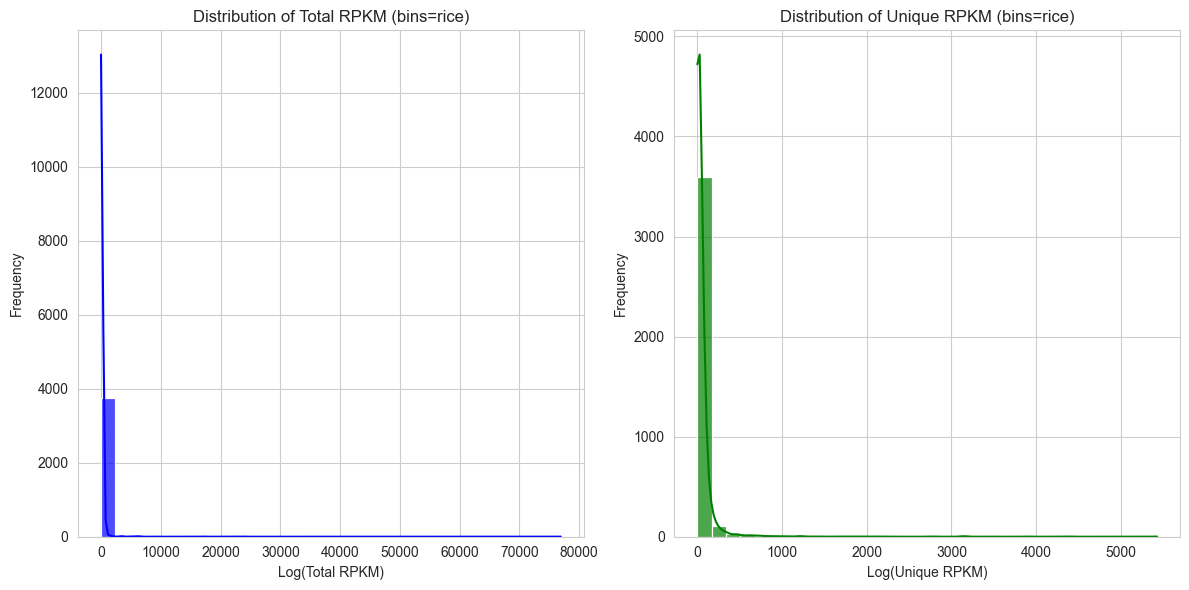

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


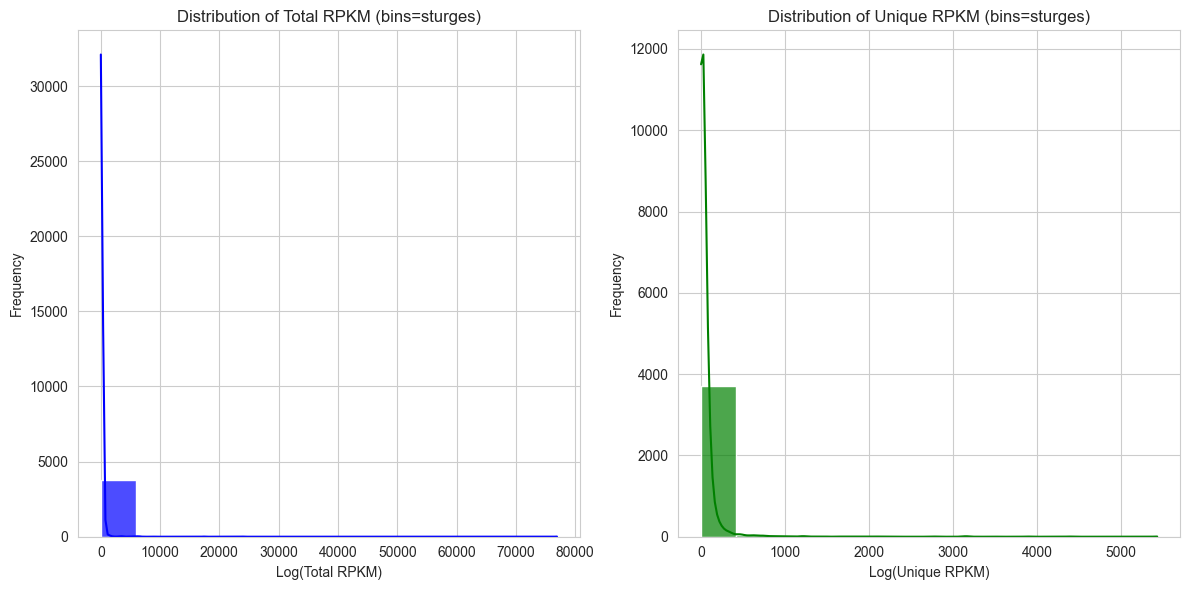

In [12]:

# Assuming rpkm_df is already defined and contains the necessary data

bin_methods = ['auto', 'fd', 'doane', 'scott', 'stone', 'rice', 'sturges']

for method in bin_methods:
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

    # Plot histogram and KDE for log(total_rpkm)
    sns.histplot(rpkm_df['total_rpkm'], bins=method, kde=True, ax=axes[0], color='blue', alpha=0.7)
    axes[0].set_title(f'Distribution of Total RPKM (bins={method})')
    axes[0].set_xlabel('Log(Total RPKM)')
    axes[0].set_ylabel('Frequency')

    # Plot histogram and KDE for log(unique_rpkm)
    sns.histplot(rpkm_df['unique_rpkm'], bins=method, kde=True, ax=axes[1], color='green', alpha=0.7)
    axes[1].set_title(f'Distribution of Unique RPKM (bins={method})')
    axes[1].set_xlabel('Log(Unique RPKM)')
    axes[1].set_ylabel('Frequency')

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


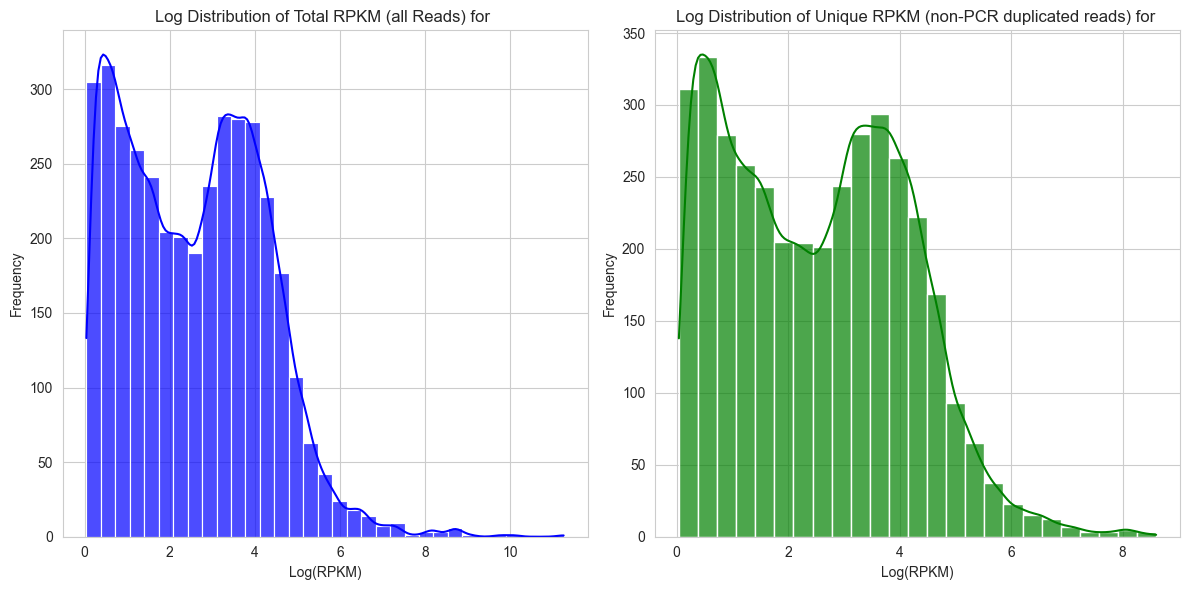

In [36]:
import matplotlib.ticker as mticker

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Plot histogram and KDE for log(total_rpkm)
sns.histplot(np.log1p(rpkm_df['total_rpkm']), bins='auto', kde=True, ax=axes[0], color='blue', alpha=0.7, kde_kws={'bw_adjust': 0.5})
axes[0].set_title(f'Log Distribution of Total RPKM (all Reads) for ')
axes[0].set_xlabel('Log(RPKM)')
axes[0].set_ylabel('Frequency')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Plot histogram and KDE for log(unique_rpkm)
sns.histplot(np.log1p(rpkm_df['unique_rpkm']), bins='auto', kde=True, ax=axes[1], color='green', alpha=0.7, kde_kws={'bw_adjust': 0.5})
axes[1].set_title(f'Log Distribution of Unique RPKM (non-PCR duplicated reads) for ')
axes[1].set_xlabel('Log(RPKM)')
axes[1].set_ylabel('Frequency')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [14]:
# fake_data = {
#     'chromosome': [str(i) for i in range(2, 24)],
#     'gene_id': [f'gene_{i}' for i in range(2, 24)],
#     'total_rpkm': np.random.rand(22) * 100,
#     'unique_rpkm': np.random.rand(22) * 100
# }
#
# fake_df = pd.DataFrame(fake_data)
#
# # Concatenate the fake data with the existing rpkm_df
# rpkm_df = pd.concat([rpkm_df, fake_df], ignore_index=True)

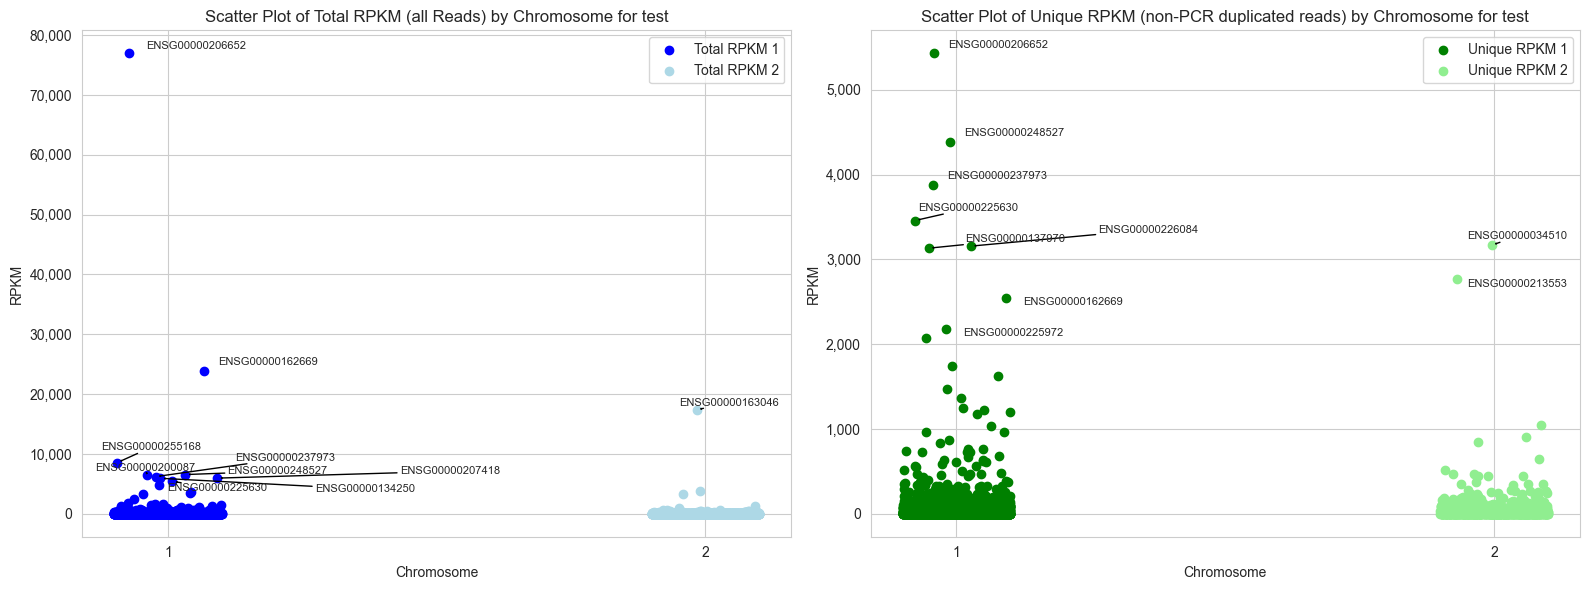

In [61]:
def roman_to_int(roman):
    """Convert Roman numeral to an integer."""
    roman_values = {
        'I': 1, 'V': 5, 'X': 10, 'L': 50, 'C': 100,
        'D': 500, 'M': 1000
    }
    prev_value = 0
    total = 0
    for char in reversed(roman):
        value = roman_values[char]
        if value < prev_value:
            total -= value
        else:
            total += value
        prev_value = value
    return total


def is_roman(s):
    """Check if a string is a valid Roman numeral."""
    roman_regex = re.compile(r'^(?=[MDCLXVI])M{0,4}(CM|CD|D?C{0,3})(XC|XL|L?X{0,3})(IX|IV|V?I{0,3})$')
    return bool(roman_regex.match(s))


def custom_key(chromosome):
    """Custom sorting key function."""
    if chromosome.isdigit():
        # Pure numeric chromosome
        return (0, int(chromosome))
    elif is_roman(chromosome):
        # Roman numeral chromosome
        return (1, roman_to_int(chromosome))
    else:
        # Alphabetical chromosome (e.g., X, Y)
        return (2, chromosome)


def custom_sort(chromosomes):
    """Sort a list of chromosome labels using the custom key."""
    return sorted(chromosomes, key=custom_key)


rpkm_df = rpkm_df.sort_values(
    by='chromosome',
    key=lambda col: col.map(custom_key)
)
# Create a new column for the x-axis positions
chromosomes = rpkm_df['chromosome'].unique()
x_positions = {chrom: i for i, chrom in enumerate(chromosomes)}
rpkm_df['x_pos'] = rpkm_df['chromosome'].map(x_positions)
from adjustText import adjust_text

# Add jitter to x positions to separate points within the same chromosome
jitter_width = 0.1
rpkm_df['x_pos_jitter_total'] = rpkm_df['x_pos'] + np.random.uniform(-jitter_width, jitter_width, size=len(rpkm_df))
rpkm_df['x_pos_jitter_unique'] = rpkm_df['x_pos'] + np.random.uniform(-jitter_width, jitter_width, size=len(rpkm_df))

# Sort by total_rpkm and unique_rpkm to find the top 20 values
top_20_total_rpkm = rpkm_df.nlargest(10, 'total_rpkm')
top_20_unique_rpkm = rpkm_df.nlargest(10, 'unique_rpkm')

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# Plot scatter plot for total_rpkm
for i, chrom in enumerate(chromosomes):
    color = 'blue' if i % 2 == 0 else 'lightblue'
    chrom_data = rpkm_df[rpkm_df['chromosome'] == chrom]
    axes[0].scatter(chrom_data['x_pos_jitter_total'], chrom_data['total_rpkm'], color=color, label=f'Total RPKM {chrom}')
axes[0].set_title(f'Scatter Plot of Total RPKM (all Reads) by Chromosome for {annotation_name}')
axes[0].set_xlabel('Chromosome')
axes[0].set_ylabel('RPKM')
axes[0].set_xticks(ticks=range(len(chromosomes)))
axes[0].set_xticklabels(chromosomes)
axes[0].legend()

# Label the top 20 values with gene_id for total_rpkm
texts_total = []
for _, row in top_20_total_rpkm.iterrows():
    texts_total.append(axes[0].text(row['x_pos_jitter_total'], row['total_rpkm'], row['gene_id'], fontsize=8))
adjust_text(texts_total, ax=axes[0], arrowprops=dict(arrowstyle='->', color='black'))

# Plot scatter plot for unique_rpkm
for i, chrom in enumerate(chromosomes):
    color = 'green' if i % 2 == 0 else 'lightgreen'
    chrom_data = rpkm_df[rpkm_df['chromosome'] == chrom]
    axes[1].scatter(chrom_data['x_pos_jitter_unique'], chrom_data['unique_rpkm'], color=color, label=f'{chrom}')
axes[1].set_title(f'Scatter Plot of Unique RPKM (non-PCR duplicated reads) by Chromosome for {annotation_name}')
axes[1].set_xlabel('Chromosome')
axes[1].set_ylabel('RPKM')
axes[1].set_xticks(ticks=range(len(chromosomes)))
axes[1].set_xticklabels(chromosomes)
axes[1].legend()

# Label the top 20 values with gene_id for unique_rpkm
texts_unique = []
for _, row in top_20_unique_rpkm.iterrows():
    texts_unique.append(axes[1].text(row['x_pos_jitter_unique'], row['unique_rpkm'], row['gene_id'], fontsize=8))
adjust_text(texts_unique, ax=axes[1], arrowprops=dict(arrowstyle='->', color='black'))

# Format y-axis with commas in the numbers
axes[0].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
axes[1].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

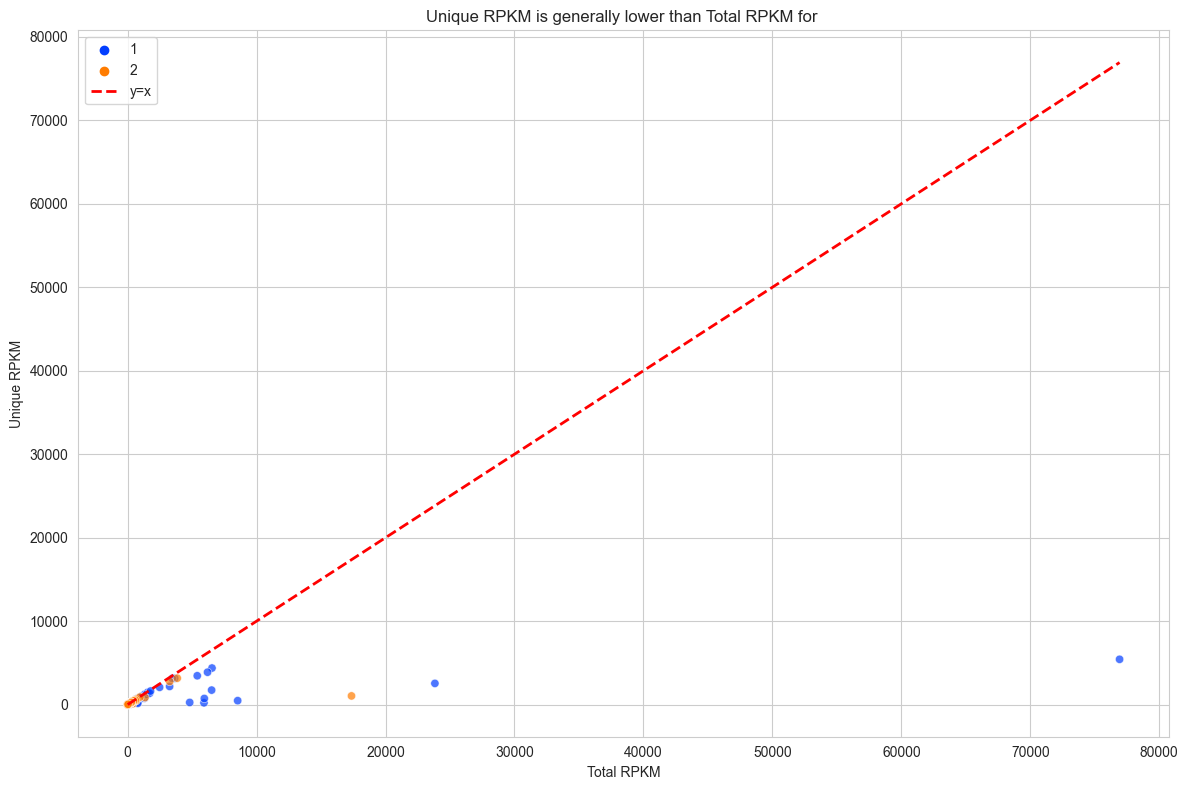

In [38]:
plt.figure(figsize=(12, 8))
scatter_plot = sns.scatterplot(
    data=rpkm_df,
    x='total_rpkm',
    y='unique_rpkm',
    hue='chromosome',
    palette='bright',  # Use a bright color palette
    alpha=0.7
)

# Add y=x line
max_value = max(rpkm_df['total_rpkm'].max(), rpkm_df['unique_rpkm'].max())
plt.plot([0, max_value], [0, max_value], color='red', linestyle='--', linewidth=2, label='y=x')

# Set plot title and labels
scatter_plot.set_title(f'Unique RPKM is generally lower than Total RPKM for ')
scatter_plot.set_xlabel('Total RPKM')
scatter_plot.set_ylabel('Unique RPKM')

# Adjust legend
scatter_plot.legend(title='Chromosome', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add label for the y=x line
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

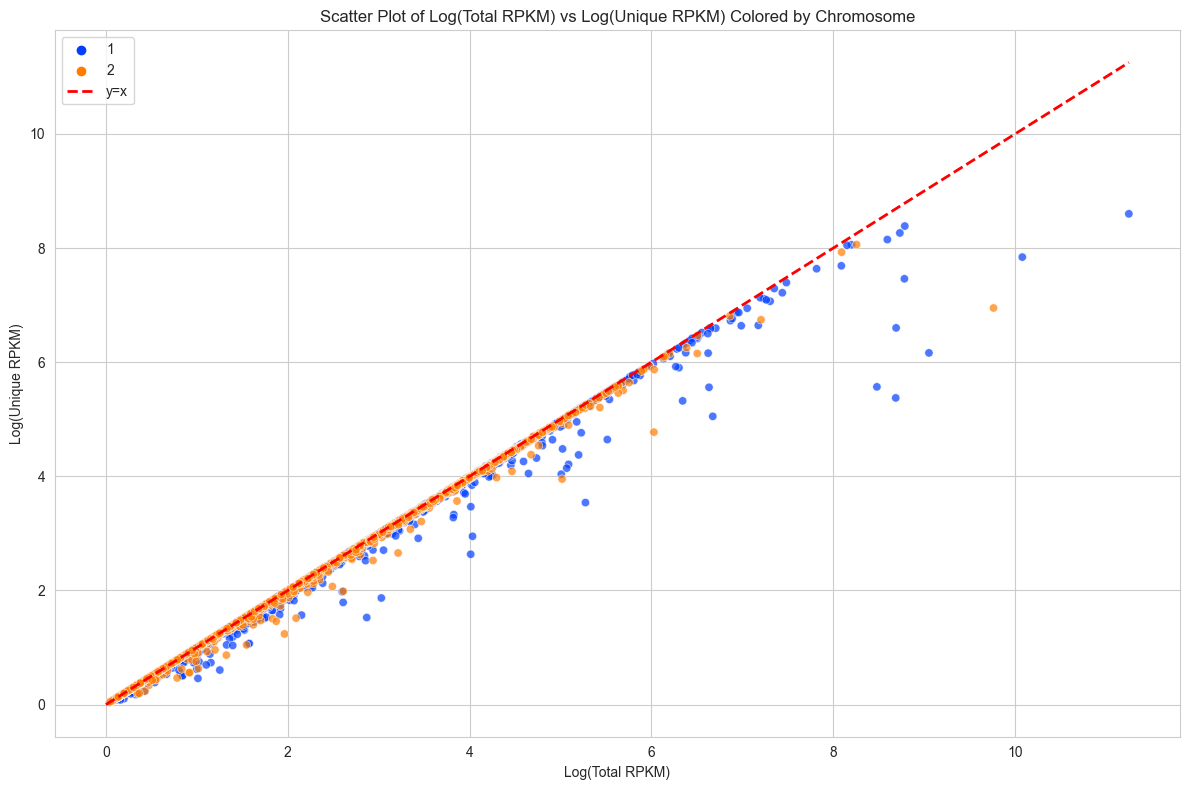

In [41]:
plt.figure(figsize=(12, 8))
scatter_plot = sns.scatterplot(
    data=rpkm_df,
    x=np.log1p(rpkm_df['total_rpkm']),
    y=np.log1p(rpkm_df['unique_rpkm']),
    hue='chromosome',
    palette='bright',  # Use a bright color palette
    alpha=0.7
)

# Add y=x line
max_value = max(np.log1p(rpkm_df['total_rpkm']).max(), np.log1p(rpkm_df['unique_rpkm']).max())
plt.plot([0, max_value], [0, max_value], color='red', linestyle='--', linewidth=2, label='y=x')

# Set plot title and labels
scatter_plot.set_title('Scatter Plot of Log(Total RPKM) vs Log(Unique RPKM) Colored by Chromosome')
scatter_plot.set_xlabel('Log(Total RPKM)')
scatter_plot.set_ylabel('Log(Unique RPKM)')

# Adjust legend
scatter_plot.legend(title='Chromosome', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add label for the y=x line
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

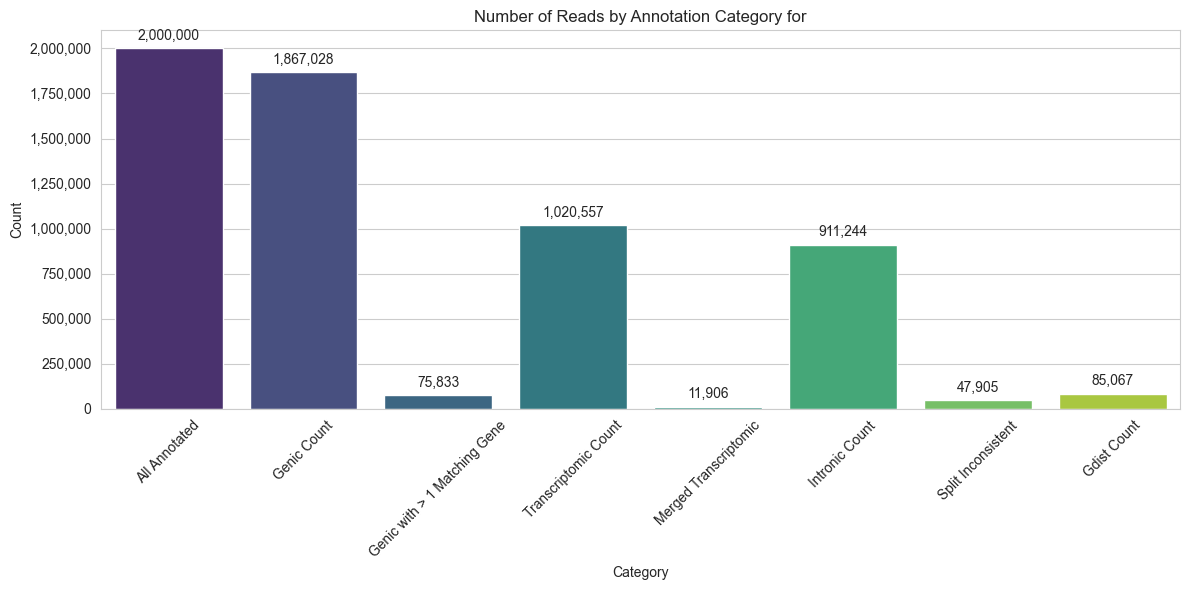

In [32]:
counts = {
    'All Annotated': all_anotated,
    'Genic Count': genic_count,
    'Genic with > 1 Matching Gene': genic_count_more_one_gene,
    'Transcriptomic Count': transcriptomic_count,
    'Merged Transcriptomic': merged_transcriptomic_count,
    'Intronic Count': intronic_count,
    'Split Inconsistent': split_inconsistent_count,
    'Gdist Count': gdist_count
}

# Create a DataFrame from the counts dictionary
counts_df = pd.DataFrame(list(counts.items()), columns=['Category', 'Count'])
# Create the bar plot
plt.figure(figsize=(12, 6))
bar_plot = sns.barplot(x='Category', y='Count', data=counts_df, palette='viridis')
# Set plot title and labels
bar_plot.set_title(f"Number of Reads by Annotation Category for")
bar_plot.set_xlabel('Category')
bar_plot.set_ylabel('Count')
# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Change y-axis to use commas
bar_plot.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Add labels above the bars with commas
for p in bar_plot.patches:
    bar_plot.annotate(format(int(p.get_height()), ','),
                      (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='center',
                      xytext=(0, 9), textcoords='offset points')

# Show the plot
plt.tight_layout()
plt.show()

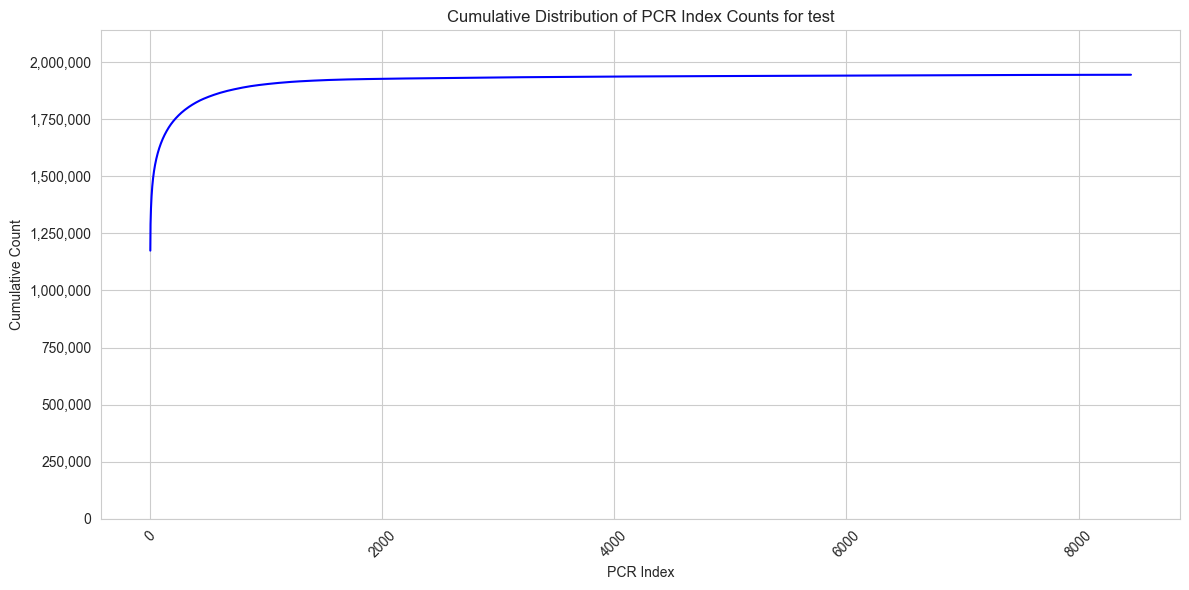

In [45]:

# Convert the pcr_index_count dictionary to a DataFrame
pcr_index_df = pd.DataFrame(list(pcr_index_count.items()), columns=['PCR Index', 'Count'])

# Convert the PCR Index column to integers
pcr_index_df['PCR Index'] = pcr_index_df['PCR Index'].astype(int)

# Sort the DataFrame by PCR Index
pcr_index_df = pcr_index_df.sort_values(by='PCR Index')

# Calculate the cumulative sum of the counts
pcr_index_df['Cumulative Count'] = pcr_index_df['Count'].cumsum()

# Plot the cumulative distribution
plt.figure(figsize=(12, 6))
plt.plot(pcr_index_df['PCR Index'], pcr_index_df['Cumulative Count'], linestyle='-', color='b')

# Set plot title and labels
plt.title(f'Cumulative Distribution of PCR Index Counts for {annotation_name}')
plt.xlabel('PCR Index')
plt.ylabel('Cumulative Count')

# Ensure the y-axis starts at 0 and format y-axis as comma numbers
plt.ylim(bottom=0, top=pcr_index_df['Cumulative Count'].max() * 1.1)
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Set x-axis to display only whole numbers at round intervals
#plt.xticks(ticks=range(pcr_index_df['PCR Index'].min(), pcr_index_df['PCR Index'].max() + 1, 2))

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()

In [42]:
annotation_name="test"

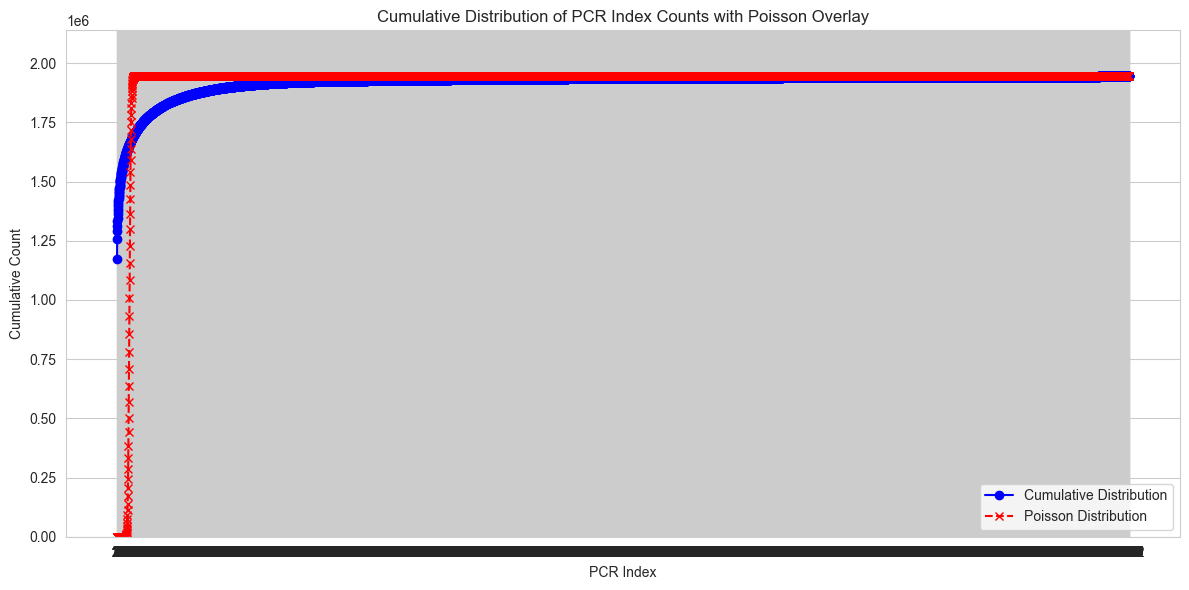

In [20]:
lambda_ = (pcr_index_df['PCR Index'] * pcr_index_df['Count']).sum() / pcr_index_df['Count'].sum()
from scipy.stats import poisson

pcr_index_df['Poisson'] = poisson.pmf(pcr_index_df['PCR Index'], lambda_) * pcr_index_df['Count'].sum()
# Plot the cumulative distribution
plt.figure(figsize=(12, 6))
plt.plot(pcr_index_df['PCR Index'], pcr_index_df['Cumulative Count'], marker='o', linestyle='-', color='b', label='Cumulative Distribution')

# Plot the Poisson distribution
plt.plot(pcr_index_df['PCR Index'], pcr_index_df['Poisson'].cumsum(), marker='x', linestyle='--', color='r', label='Poisson Distribution')

# Set plot title and labels
plt.title('Cumulative Distribution of PCR Index Counts with Poisson Overlay')
plt.xlabel('PCR Index')
plt.ylabel('Cumulative Count')

# Ensure the y-axis starts at 0
plt.ylim(bottom=0, top=pcr_index_df['Cumulative Count'].max() * 1.1)
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
# Set x-axis to display only whole numbers
plt.xticks(ticks=range(pcr_index_df['PCR Index'].min(), pcr_index_df['PCR Index'].max() + 1))

# Show legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

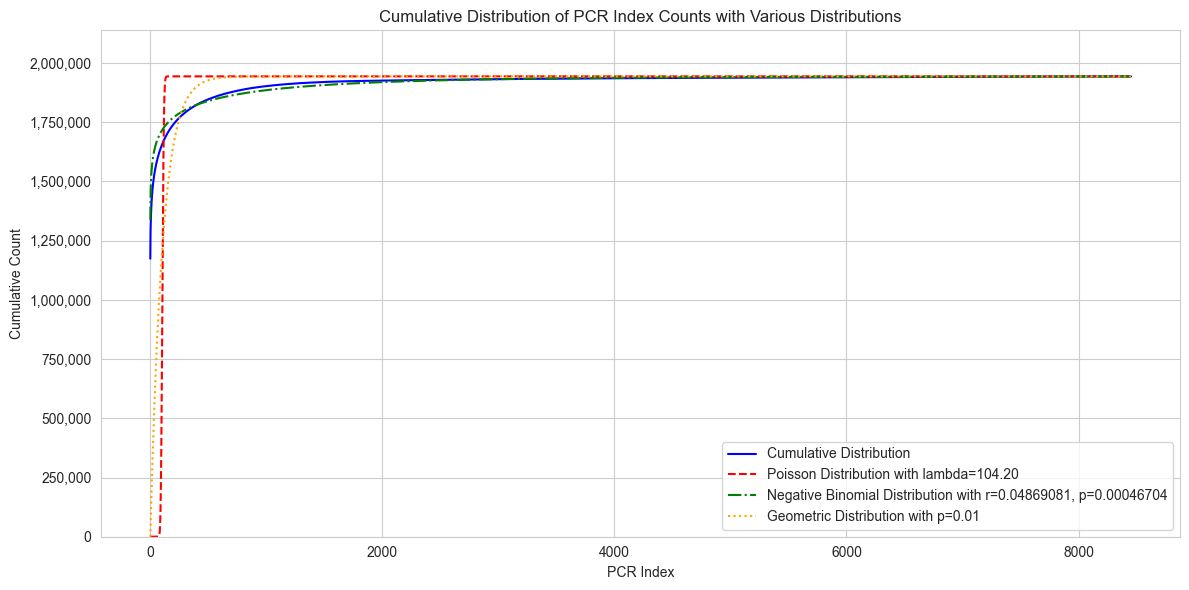

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom, geom

# Assuming pcr_index_df has columns: 'PCR Index', 'Count'
# Calculate lambda for Poisson
lambda_ = (pcr_index_df['PCR Index'] * pcr_index_df['Count']).sum() / pcr_index_df['Count'].sum()

# Calculate parameters for Negative Binomial
mean_pcr = lambda_
variance_pcr = ((pcr_index_df['PCR Index'] ** 2 * pcr_index_df['Count']).sum() / pcr_index_df['Count'].sum()) - mean_pcr ** 2
r = mean_pcr ** 2 / (variance_pcr - mean_pcr)  # Dispersion parameter
p_nb = r / (r + mean_pcr)

# Calculate parameter for Geometric
p_geom = 1 / (mean_pcr + 1)

# Prepare distributions
pcr_index_df['Poisson'] = poisson.pmf(pcr_index_df['PCR Index'], lambda_) * pcr_index_df['Count'].sum()
pcr_index_df['Negative Binomial'] = nbinom.pmf(pcr_index_df['PCR Index'], r, p_nb) * pcr_index_df['Count'].sum()
pcr_index_df['Geometric'] = geom.pmf(pcr_index_df['PCR Index'], p_geom) * pcr_index_df['Count'].sum()

# Plot cumulative distributions
plt.figure(figsize=(12, 6))
plt.plot(pcr_index_df['PCR Index'], pcr_index_df['Cumulative Count'], linestyle='-', color='b',
         label='Cumulative Distribution')
plt.plot(pcr_index_df['PCR Index'], pcr_index_df['Poisson'].cumsum(), linestyle='--', color='r',
         label=f'Poisson Distribution with lambda={lambda_:.2f}')
plt.plot(pcr_index_df['PCR Index'], pcr_index_df['Negative Binomial'].cumsum(),  linestyle='-.',
         color='g', label=f'Negative Binomial Distribution with r={r:.8f}, p={p_nb:.8f}')
plt.plot(pcr_index_df['PCR Index'], pcr_index_df['Geometric'].cumsum(), linestyle=':', color='orange',
         label=f'Geometric Distribution with p={p_geom:.2f}')

# Set plot title and labels
plt.title('Cumulative Distribution of PCR Index Counts with Various Distributions')
plt.xlabel('PCR Index')
plt.ylabel('Cumulative Count')

# Ensure the y-axis starts at 0
plt.ylim(bottom=0, top=pcr_index_df['Cumulative Count'].max() * 1.1)
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
# Set x-axis to display only whole numbers
#plt.xticks(ticks=range(pcr_index_df['PCR Index'].min(), pcr_index_df['PCR Index'].max() + 1))

# Show legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

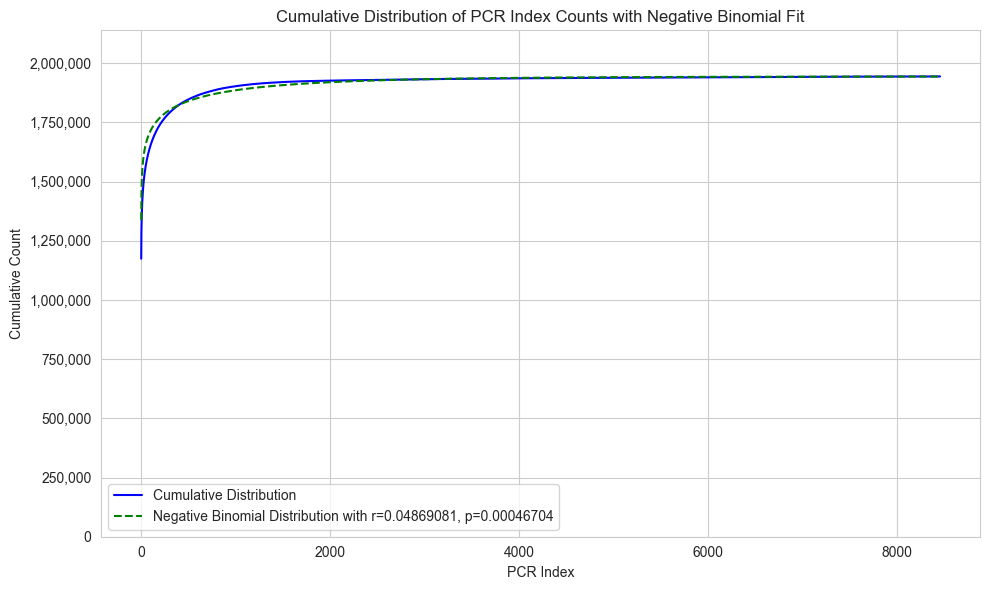

In [56]:
# Plot cumulative distribution with Negative Binomial overlay
plt.figure(figsize=(10, 6))
plt.plot(pcr_index_df['PCR Index'], pcr_index_df['Cumulative Count'], linestyle='-', color='b', label='Cumulative Distribution')
plt.plot(pcr_index_df['PCR Index'], pcr_index_df['Negative Binomial'].cumsum(),  linestyle='--', color='g', label=f'Negative Binomial Distribution with r={r:.8f}, p={p_nb:.8f}')

# Set plot title and labels
plt.title('Cumulative Distribution of PCR Index Counts with Negative Binomial Fit')
plt.xlabel('PCR Index')
plt.ylabel('Cumulative Count')

# Ensure the y-axis starts at 0
plt.ylim(bottom=0, top=pcr_index_df['Cumulative Count'].max() * 1.1)
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
# Set x-axis to display only whole numbers
#plt.xticks(ticks=range(pcr_index_df['PCR Index'].min(), pcr_index_df['PCR Index'].max() + 1))

# Show legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

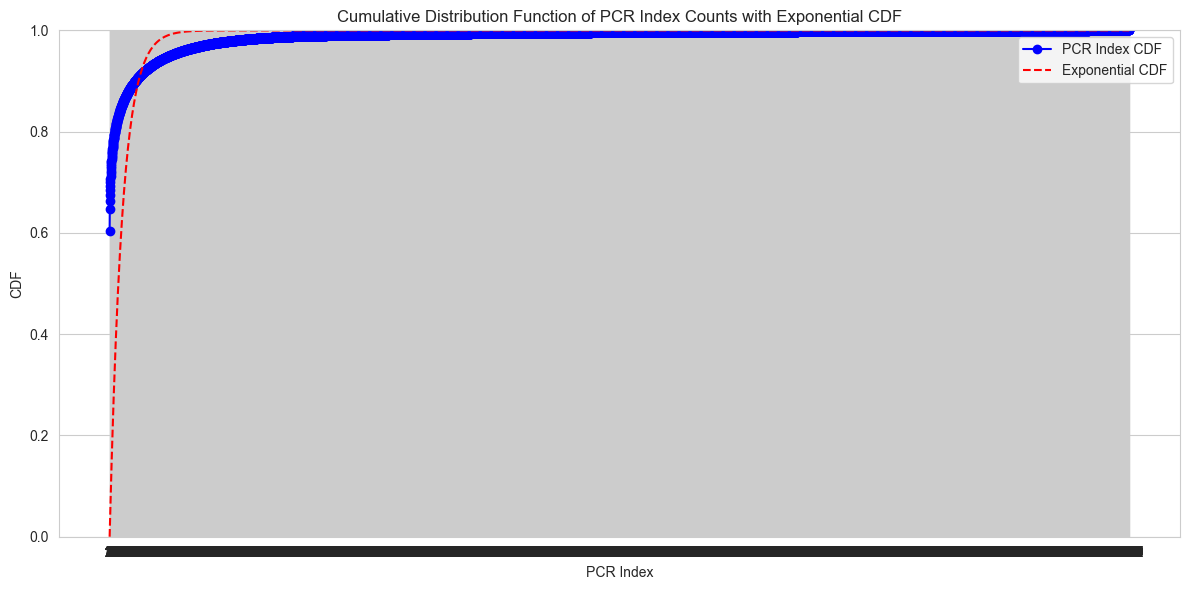

In [23]:
pcr_index_df = pd.DataFrame(list(pcr_index_count.items()), columns=['PCR Index', 'Count'])

# Convert the PCR Index column to integers
pcr_index_df['PCR Index'] = pcr_index_df['PCR Index'].astype(int)

# Sort the DataFrame by PCR Index
pcr_index_df = pcr_index_df.sort_values(by='PCR Index')

# Calculate the cumulative sum of the counts
pcr_index_df['Cumulative Count'] = pcr_index_df['Count'].cumsum()

# Calculate the CDF
pcr_index_df['CDF'] = pcr_index_df['Cumulative Count'] / pcr_index_df['Cumulative Count'].max()

# Calculate the mean of the PCR Index counts
weighted_mean_pcr_index = (pcr_index_df['PCR Index'] * pcr_index_df['Count']).sum() / pcr_index_df['Count'].sum()
# Calculate lambda (λ) as the inverse of the mean
lambda_param = 1 / weighted_mean_pcr_index

# Generate the exponential CDF
# Generate a finer range of x_values for a smoother curve
x_values = np.linspace(pcr_index_df['PCR Index'].min(), pcr_index_df['PCR Index'].max(), num=1000)
exponential_cdf = 1 - np.exp(-lambda_param * x_values)

# Plot the CDF of the PCR index counts
plt.figure(figsize=(12, 6))
plt.plot(pcr_index_df['PCR Index'], pcr_index_df['CDF'], marker='o', linestyle='-', color='b', label='PCR Index CDF')

# Plot the exponential CDF
plt.plot(x_values, exponential_cdf, linestyle='--', color='r', label='Exponential CDF')

# Set plot title and labels
plt.title('Cumulative Distribution Function of PCR Index Counts with Exponential CDF')
plt.xlabel('PCR Index')
plt.ylabel('CDF')

# Ensure the y-axis starts at 0
plt.ylim(bottom=0, top=1)

# Set x-axis to display only whole numbers
plt.xticks(ticks=range(pcr_index_df['PCR Index'].min(), pcr_index_df['PCR Index'].max() + 1))

# Show legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

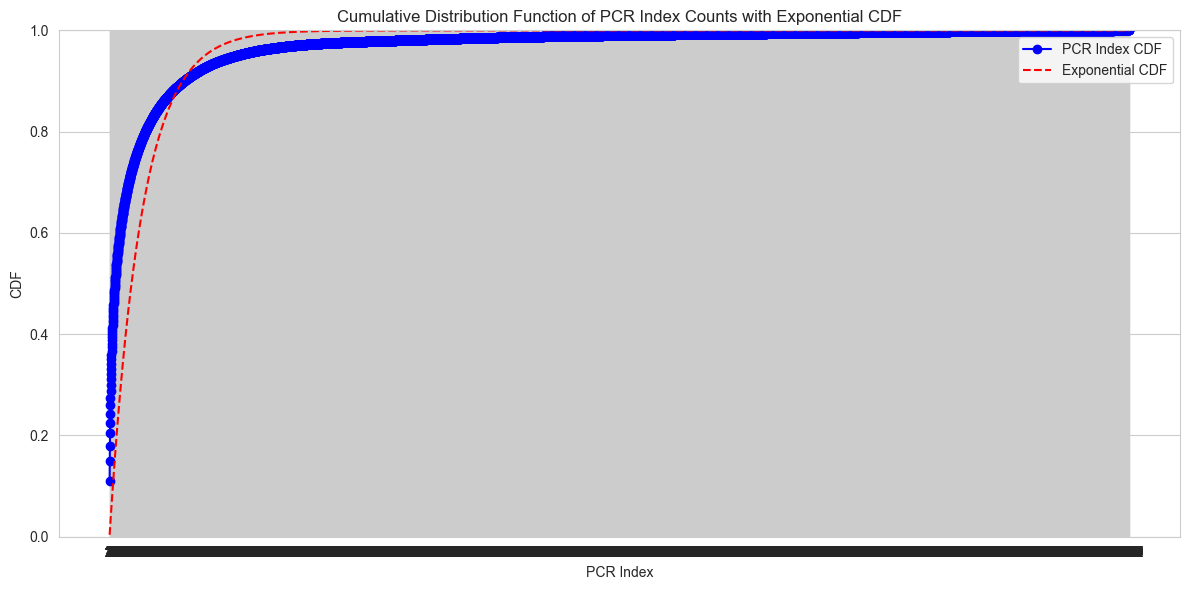

In [24]:
# Convert the pcr_index_count dictionary to a DataFrame
pcr_index_df = pd.DataFrame(list(pcr_index_count.items()), columns=['PCR Index', 'Count'])

# Convert the PCR Index column to integers
pcr_index_df['PCR Index'] = pcr_index_df['PCR Index'].astype(int)

# Exclude PCR index 0
pcr_index_df = pcr_index_df[pcr_index_df['PCR Index'] != 0]

# Sort the DataFrame by PCR Index
pcr_index_df = pcr_index_df.sort_values(by='PCR Index')

# Calculate the cumulative sum of the counts
pcr_index_df['Cumulative Count'] = pcr_index_df['Count'].cumsum()

# Calculate the CDF
pcr_index_df['CDF'] = pcr_index_df['Cumulative Count'] / pcr_index_df['Cumulative Count'].max()

# Calculate the weighted mean of the PCR Index counts
weighted_mean_pcr_index = (pcr_index_df['PCR Index'] * pcr_index_df['Count']).sum() / pcr_index_df['Count'].sum()

# Calculate lambda (λ) as the inverse of the weighted mean
lambda_param = 1 / weighted_mean_pcr_index

# Generate the exponential CDF using MLE
x_values = np.arange(pcr_index_df['PCR Index'].min(), pcr_index_df['PCR Index'].max() + 1)
exponential_cdf = 1 - np.exp(-lambda_param * x_values)

# Plot the CDF of the PCR index counts
plt.figure(figsize=(12, 6))
plt.plot(pcr_index_df['PCR Index'], pcr_index_df['CDF'], marker='o', linestyle='-', color='b', label='PCR Index CDF')

# Plot the exponential CDF
plt.plot(x_values, exponential_cdf, linestyle='--', color='r', label='Exponential CDF')

# Set plot title and labels
plt.title('Cumulative Distribution Function of PCR Index Counts with Exponential CDF')
plt.xlabel('PCR Index')
plt.ylabel('CDF')

# Ensure the y-axis starts at 0
plt.ylim(bottom=0, top=1)

# Set x-axis to display only whole numbers
plt.xticks(ticks=range(pcr_index_df['PCR Index'].min(), pcr_index_df['PCR Index'].max() + 1))

# Show legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

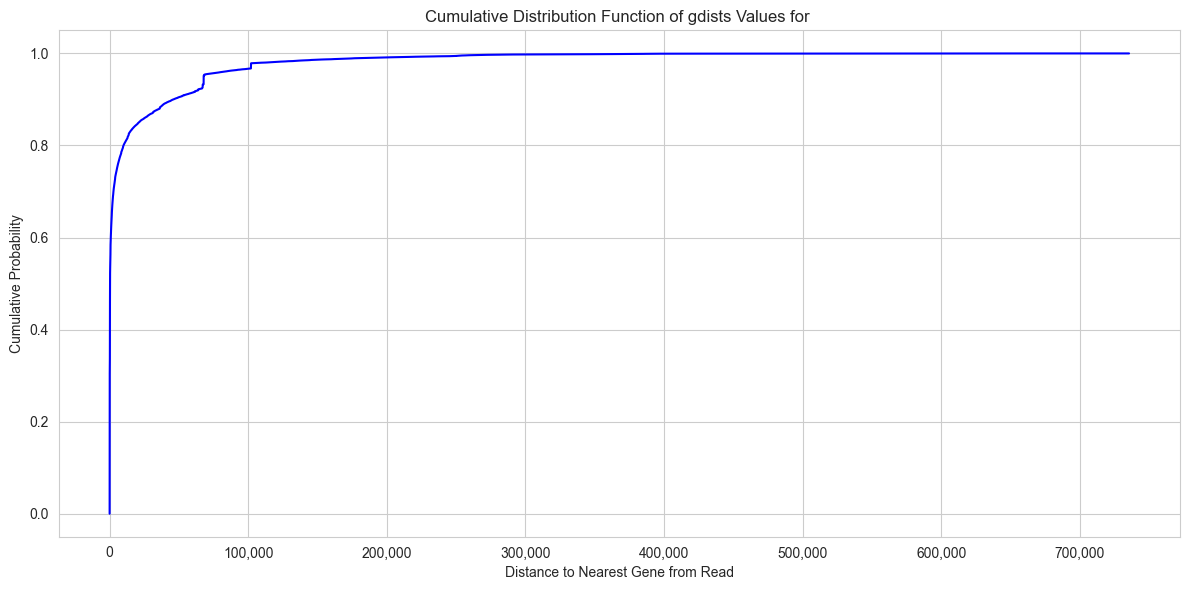

In [35]:
from matplotlib.ticker import MaxNLocator

gdist_array = np.sort(np.array(gdists).astype(int))
# Calculate the cumulative counts
cum_counts = np.arange(1, len(gdist_array) + 1)
# Create a DataFrame for plotting
gdist_df = pd.DataFrame({
    'Value': gdist_array,
    'Cumulative Count': cum_counts
})
# Calculate the CDF
gdist_df['CDF'] = gdist_df['Cumulative Count'] / gdist_df['Cumulative Count'].max()
# Plot the CDF
plt.figure(figsize=(12, 6))
plt.plot(gdist_df['Value'], gdist_df['CDF'], linestyle='-', color='b')
# Set plot title and labels
plt.title(f'Cumulative Distribution Function of gdists Values for ')
plt.xlabel('Distance to Nearest Gene from Read')
plt.ylabel('Cumulative Probability')
# Determine appropriate tick intervals
min_value = gdist_df['Value'].min()
max_value = gdist_df['Value'].max()
# Set tick interval (adjust as needed)
tick_interval = 500  # For example, every 500 units
ticks = np.arange(min_value, max_value + tick_interval, tick_interval)
# Adjust x-axis ticks to reduce clutter
plt.xticks(ticks=ticks)
# Limit the number of x-axis ticks
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True, prune='both'))
# Format x-axis labels with commas and scientific notation
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
# Show the plot
plt.tight_layout()
plt.show()

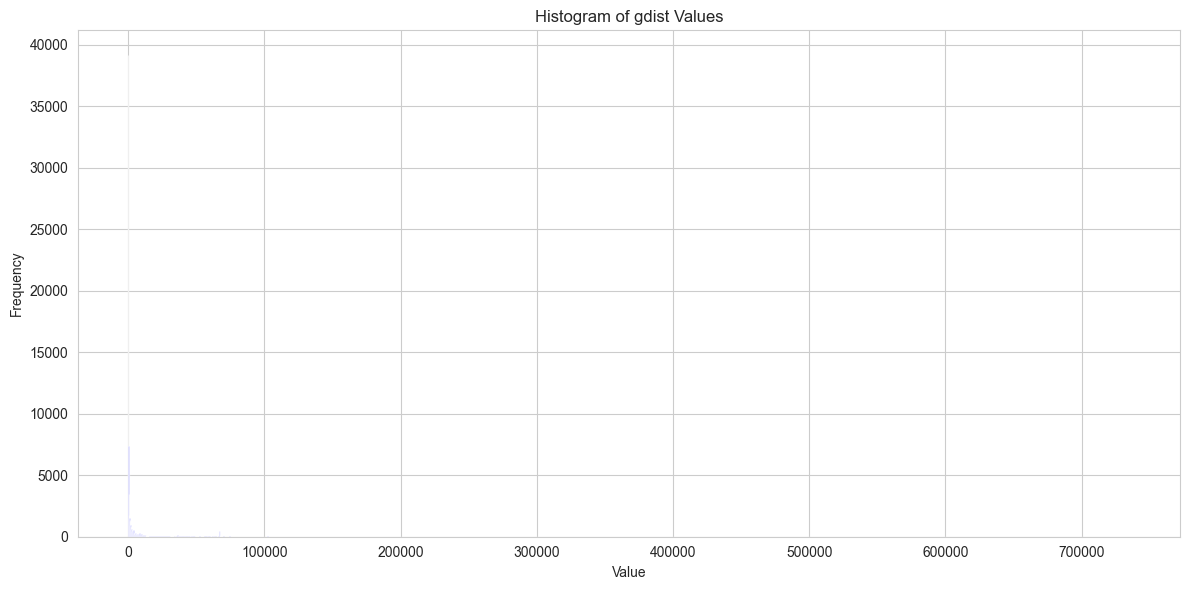

In [26]:
gdist_int = np.array(gdists).astype(int)

# Plot the histogram
plt.figure(figsize=(12, 6))
plt.hist(gdist_int, bins='auto', color='b', alpha=0.7, rwidth=0.85)

# Set plot title and labels
plt.title('Histogram of gdist Values')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Show the plot
plt.tight_layout()
plt.show()